In [ ]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import pyrepseq as prs
import utils
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests
from typing import Literal
from scipy import stats
from joblib import Parallel, delayed
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [7]:
td_df = pd.read_csv("datasets/merge_spc2.csv")
td_df['v.alpha'] = td_df['v.alpha'].map(lambda x: x.split('*')[0])
td_df['v.beta'] = td_df['v.beta'].map(lambda x: x.split('*')[0])
td_df['j.alpha'] = td_df['j.alpha'].map(lambda x: x.split('*')[0])
td_df['j.beta'] = td_df['j.beta'].map(lambda x: x.split('*')[0])
#td_df = td_df.drop_duplicates(subset=['v.alpha', 'v.beta', 'cdr3.alpha', 'cdr3.beta',
#                                      'j.alpha', 'j.beta', 'antigen.epitope'])

HLA0201 = td_df.loc[td_df['mhc.a'].str.contains('HLA-A*02:01', na=False, regex=False)]
HLA0301 = td_df.loc[td_df['mhc.a'].str.contains('HLA-A*03:01', na=False, regex=False)]
HLAII = td_df.loc[~td_df['mhc.a'].str.contains('HLA-[ABC]', na=False, regex=True)]
HLAI = td_df.loc[td_df['mhc.a'].str.contains('HLA-[ABC]', na=False, regex=True)]
otherHLA = HLAI.loc[~(HLAI['mhc.a'].str.contains('HLA-A*02:01', na=False, regex=False) | 
                          HLAI['mhc.a'].str.contains('HLA-A*03:01', na=False, regex=False))]

In [8]:
HLA_df = []
hlaalleles = pd.read_csv("datasets/processed_Allelelist.txt")
# 將資料依照 HLA 類型分類
for hla in hlaalleles['Allele'].unique():
    temp = td_df.loc[td_df['mhc.a'].str.contains(hla, na=False, regex=False)]
    temp['mhc.a'] = hla
    HLA_df.append(temp.drop_duplicates(subset=['v.alpha', 'v.beta', 'cdr3.alpha', 'cdr3.beta',
                                      'j.alpha', 'j.beta']))

HLA_df = pd.concat(HLA_df)
HLA_df = HLA_df.rename(columns={'v.alpha':'TRAV', 'v.beta':'TRBV', 'j.alpha':'TRAJ', 'j.beta':'TRBJ',
                                'cdr3.alpha':'CDR3A', 'cdr3.beta':'CDR3B'})
print(HLA_df.shape, HLA_df['mhc.a'].unique().shape)

valpha_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'TRAV', 'mhc.a')
vbeta_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'TRBV', 'mhc.a')
HLA_df['v.gene'] = HLA_df['TRAV'].str.cat(HLA_df['TRBV'], sep=":")
v_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'v.gene', 'mhc.a')

print(valpha_nmi_value, vbeta_nmi_value, v_nmi_value)

jalpha_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'TRAJ', 'mhc.a')
jbeta_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'TRBJ', 'mhc.a')
HLA_df['j.gene'] = HLA_df['TRAJ'].str.cat(HLA_df['TRBJ'], sep=":")
j_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'j.gene', 'mhc.a')
print(jalpha_nmi_value, jbeta_nmi_value, j_nmi_value)

calpha_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'CDR3A', 'mhc.a')
cbeta_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'CDR3B', 'mhc.a')
c_nmi_value = utils.compute_normalized_mutual_information(HLA_df, 'full.seq', 'mhc.a')
print(calpha_nmi_value, cbeta_nmi_value, c_nmi_value)

/tmp/ipykernel_2548/2338301265.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['mhc.a'] = hla


(35821, 12) (87,)
0.07673635709408491 0.058369582631078096 0.1419579465293492
0.0565931734273445 0.023377082723424862 0.08963535363482003
0.2870955289926757 0.29498086063471685 0.2939864952285705


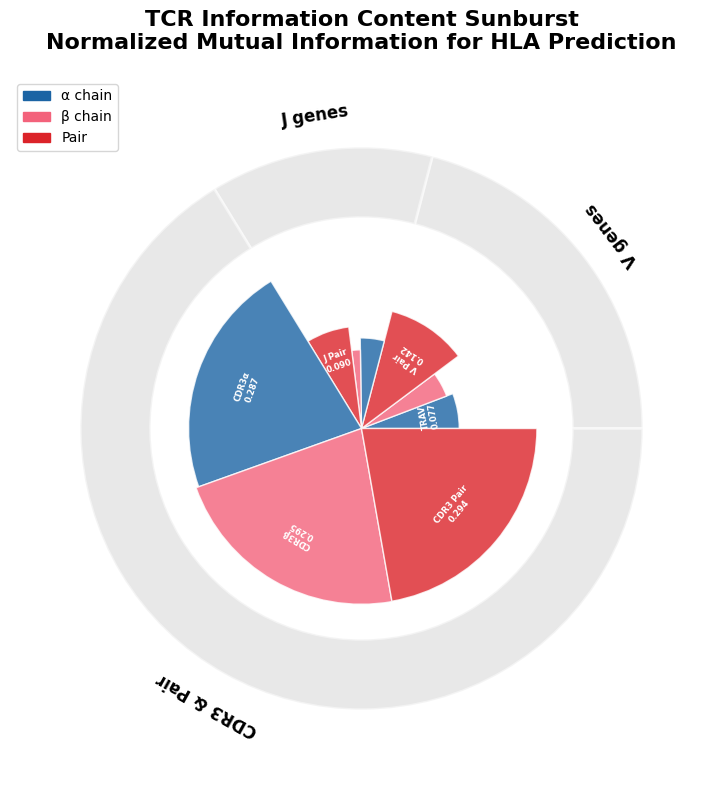

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8,8))

# Data organization
data = {
    'V genes': {'TRAV': valpha_nmi_value, 'TRBV': vbeta_nmi_value, 'V Pair': v_nmi_value},
    'J genes': {'TRAJ': jalpha_nmi_value, 'TRBJ': jbeta_nmi_value, 'J Pair': j_nmi_value},
    'CDR3 & Pair': {'CDR3α': calpha_nmi_value, 'CDR3β': cbeta_nmi_value, 'CDR3 Pair': c_nmi_value}
}

# Colors - only three colors needed
colors = {
    'α chain': '#1B64A4', 
    'β chain': '#F3627B', 
    'Pair': '#DB2329'
}

# Calculate angles
total_value = sum([sum(subdata.values()) for subdata in data.values()])
start_angle = 0

for category, subdata in data.items():
    category_total = sum(subdata.values())
    category_angle = (category_total / total_value) * 360
    
    # Draw outer ring (category)
    wedge_outer = Wedge((0, 0), 4, start_angle, start_angle + category_angle,
                       width=1, facecolor='lightgray', alpha=0.5, 
                       edgecolor='white', linewidth=2)
    ax.add_patch(wedge_outer)
    
    # Add category label
    mid_angle = start_angle + category_angle/2
    label_x = 4.5 * np.cos(np.radians(mid_angle))
    label_y = 4.5 * np.sin(np.radians(mid_angle))
    ax.text(label_x, label_y, category, ha='center', va='center',
            fontsize=12, fontweight='bold', 
            rotation=mid_angle-90 if mid_angle > 90 and mid_angle < 270 else mid_angle+90)
    
    # Draw inner segments (components)
    sub_start = start_angle
    for comp_name, comp_value in subdata.items():
        comp_angle = (comp_value / category_total) * category_angle
        
        # Determine color - simplified logic for three colors only
        if 'α' in comp_name or 'TRAV' in comp_name or 'TRAJ' in comp_name:
            color = colors['α chain']
        elif 'β' in comp_name or 'TRBV' in comp_name or 'TRBJ' in comp_name:
            color = colors['β chain']
        else:  # All pair/combined components
            color = colors['Pair']
        
        # Inner ring radius proportional to value
        inner_radius = 1 + (comp_value / max([max(d.values()) for d in data.values()])) * 1.5
        
        wedge_inner = Wedge((0, 0), inner_radius, sub_start, sub_start + comp_angle,
                           facecolor=color, alpha=0.8, edgecolor='white', linewidth=1)
        ax.add_patch(wedge_inner)
        
        # Add value labels for larger segments
        if comp_angle > 20:
            mid_comp_angle = sub_start + comp_angle/2
            text_radius = inner_radius * 0.7
            text_x = text_radius * np.cos(np.radians(mid_comp_angle))
            text_y = text_radius * np.sin(np.radians(mid_comp_angle))
            ax.text(text_x, text_y, f'{comp_name}\n{comp_value:.3f}', 
                   ha='center', va='center', fontsize=6, fontweight='bold',
                   color='white', 
                   rotation=mid_comp_angle-90 if mid_comp_angle > 90 and mid_comp_angle < 270 else mid_comp_angle+90)
        
        sub_start += comp_angle
    
    start_angle += category_angle

# Customize plot
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('TCR Information Content Sunburst\nNormalized Mutual Information for HLA Prediction', 
             fontsize=16, fontweight='bold', pad=20)

# Legend - only three colors
legend_elements = [mpatches.Patch(color=colors['α chain'], label='α chain'),
                   mpatches.Patch(color=colors['β chain'], label='β chain'),
                   mpatches.Patch(color=colors['Pair'], label='Pair')]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.savefig("/mnt/d/TCRMI/figures/HLA/NMI_for_HLA_prediction.pdf", transparent=True)

In [4]:
cached_backgrounds = np.load("results/twins/cached_backgrouds.npy", allow_pickle=True).item()

In [5]:
features = ["CDR3A", "TRAV", "TRAJ"]
alpha_relevancy_grid = np.zeros((len(features), len(features)))
for i, feature_1 in enumerate(features):
    for j, feature_2 in enumerate(features[i:], start=i): 
        if feature_1 == feature_2:
            alpha_relevancy_grid[i, j] = cached_backgrounds[feature_1] - prs.renyi2_entropy(HLA_df, feature_1, "mhc.a")
        else:
            alpha_relevancy_grid[i, j] = cached_backgrounds[(feature_1, feature_2)] - prs.renyi2_entropy(HLA_df, [feature_1, feature_2], "mhc.a")
        if i != j:
            alpha_relevancy_grid[j, i] = alpha_relevancy_grid[i, j] 
    
features = ["CDR3B", "TRBV", "TRBJ"]
beta_relevancy_grid = np.zeros((len(features), len(features)))
for i, feature_1 in enumerate(features):
    for j, feature_2 in enumerate(features[i:], start=i): 
        if feature_1 == feature_2:
            beta_relevancy_grid[i, j] = cached_backgrounds[feature_1] - prs.renyi2_entropy(HLA_df, feature_1, "mhc.a")
        else:
            beta_relevancy_grid[i, j] = cached_backgrounds[(feature_1, feature_2)] - prs.renyi2_entropy(HLA_df, [feature_1, feature_2], "mhc.a")
        if i != j:
            beta_relevancy_grid[j, i] = beta_relevancy_grid[i, j]

features_1 = ["CDR3A", "TRAV", "TRAJ"]
features_2 = ["CDR3B", "TRBV", "TRBJ"]
relevancy_grid = np.zeros((len(features_1), len(features_2)))
for i, feature1 in enumerate(features_1):
        for j, feature2 in enumerate(features_2):
            relevancy_grid[i, j] = cached_backgrounds[feature1] + cached_backgrounds[feature2] - prs.renyi2_entropy(HLA_df, [feature1, feature2], "mhc.a")

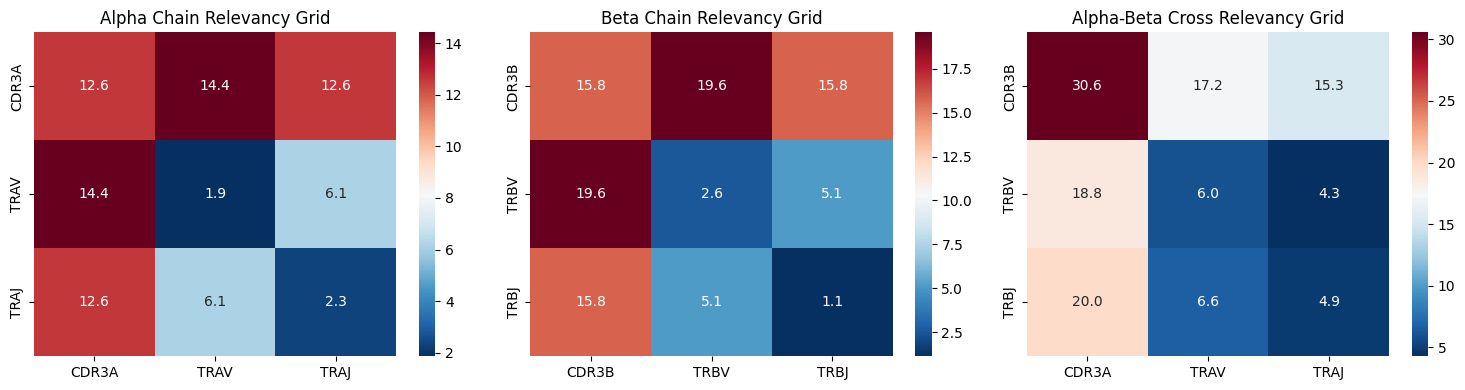

In [6]:
# Display the grids with proper labels
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Alpha chain relevancy grid
features_alpha = ["CDR3A", "TRAV", "TRAJ"]
sns.heatmap(alpha_relevancy_grid, 
            xticklabels=features_alpha, 
            yticklabels=features_alpha,
            annot=True, fmt='.1f', 
            ax=axes[0], cmap='RdBu_r')
axes[0].set_title('Alpha Chain Relevancy Grid')

# Beta chain relevancy grid  
features_beta = ["CDR3B", "TRBV", "TRBJ"]
sns.heatmap(beta_relevancy_grid,
            xticklabels=features_beta,
            yticklabels=features_beta, 
            annot=True, fmt='.1f',
            ax=axes[1], cmap='RdBu_r')
axes[1].set_title('Beta Chain Relevancy Grid')

# Cross-chain relevancy grid
sns.heatmap(relevancy_grid,
            xticklabels=features_alpha,
            yticklabels=features_beta,
            annot=True, fmt='.1f',
            ax=axes[2], cmap='RdBu_r')
axes[2].set_title('Alpha-Beta Cross Relevancy Grid')

plt.tight_layout()
#plt.savefig("/mnt/d/TCRMI/figures/HLA/conincidence_mi_between_TCR_sections.pdf", transparent=True)

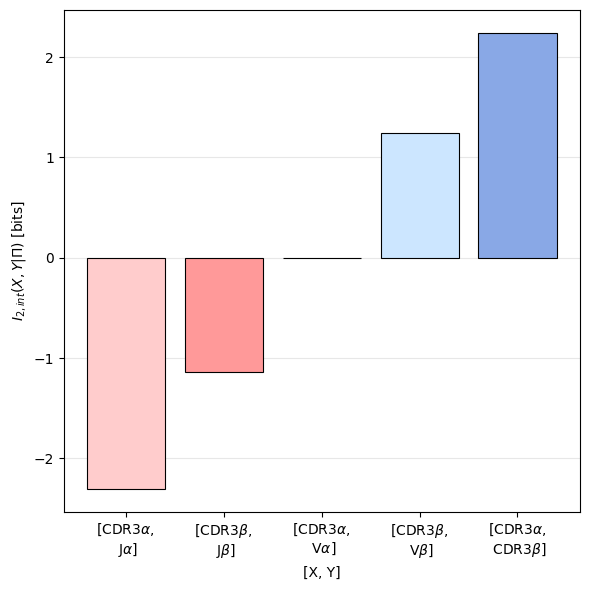

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

values = [
    alpha_relevancy_grid[0, 2] - alpha_relevancy_grid[0, 0] - alpha_relevancy_grid[2, 2],
    beta_relevancy_grid[0, 2] - beta_relevancy_grid[0, 0] - beta_relevancy_grid[2, 2],
    alpha_relevancy_grid[0, 1] - alpha_relevancy_grid[0, 0] - alpha_relevancy_grid[1, 1],
    beta_relevancy_grid[0, 1] - beta_relevancy_grid[0, 0] - beta_relevancy_grid[1, 1],
    relevancy_grid[0, 0] - alpha_relevancy_grid[0, 0] - beta_relevancy_grid[0, 0],
]

# 分離正負值並排序
positive_indices = [i for i, v in enumerate(values) if v >= 0]
negative_indices = [i for i, v in enumerate(values) if v < 0]

positive_values = [(i, values[i]) for i in positive_indices]
negative_values = [(i, values[i]) for i in negative_indices]

# 按值排序
positive_values.sort(key=lambda x: x[1])
negative_values.sort(key=lambda x: x[1])

# 創建顏色映射
colors = ['white'] * len(values)  # 初始化

# 為正值分配不同深度的藍色
blue_colors = ['#cce6ff', "#89a8e6", "#5886e8", '#0066cc', '#003d7a']
for rank, (idx, val) in enumerate(positive_values):
    if rank < len(blue_colors):
        colors[idx] = blue_colors[rank]
    else:
        colors[idx] = blue_colors[-1]

# 為負值分配不同深度的紅色
red_colors = ['#ffcccc', '#ff9999', '#ff6666', '#ff3333', '#cc0000']
for rank, (idx, val) in enumerate(negative_values):
    if rank < len(red_colors):
        colors[idx] = red_colors[rank]
    else:
        colors[idx] = red_colors[-1]

# 繪製長條圖
bars_plot = ax.bar(range(len(values)), values, color=colors, edgecolor='black', linewidth=0.8)

ax.set_ylabel("$I_{2, int}(X, Y|\Pi)$ [bits]")
ax.set_xlabel("[X, Y]")
bars = [#"[V$\\alpha$, \n V$\\beta$]", "[J$\\alpha$, \n J$\\beta$]",
       "[CDR3$\\alpha$, \n J$\\alpha$]", "[CDR3$\\beta$, \n J$\\beta$]",
        "[CDR3$\\alpha$, \n V$\\alpha$]", "[CDR3$\\beta$, \n V$\\beta$]",
       "[CDR3$\\alpha$, \n CDR3$\\beta$]"]
ax.set_xticks(np.arange(len(bars)), bars)

ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
#plt.savefig("/mnt/d/TCRMI/figures/HLA/synergistic_and_redundant_TCRfeatures.pdf", transparent=True)


In [11]:
import scipy.odr as odr  # Add missing import
import string  # Add missing import

def round_up(x, decimal_places):
    return np.ceil(x * 10**decimal_places) / 10**decimal_places

def linear_func(p, x):
    a, b = p
    return a*x + b
 
def fixed_negative_gradient_func(p, x):  # Fixed: p should be parameter, not b
    b = p[0] if isinstance(p, (list, tuple, np.ndarray)) else p  # Handle both single value and array
    return -x + b

def fixed_positive_gradient_func(p, x):  # Fixed: p should be parameter, not b
    b = p[0] if isinstance(p, (list, tuple, np.ndarray)) else p  # Handle both single value and array
    return x + b
 
def plot_fit(x, y, func, beta0, x_to_plot, ax, color, linestyle='-', intervals=True, title=True, decimal_places=1, *args, **kwargs):
    model = odr.Model(func)
    
    data = odr.RealData(x, y, *args, **kwargs)
    odr_fit = odr.ODR(data, model, beta0=beta0)  # Fixed: renamed variable to avoid conflict
    out = odr_fit.run()
    
    ax.plot(x_to_plot, func(out.beta, x_to_plot), c=color, linestyle=linestyle)
    
    if intervals:
        ps = np.random.multivariate_normal(out.beta, out.cov_beta, 10000)
        ysample = np.asarray([func(pi, x_to_plot) for pi in ps])
        lower_bound = np.percentile(ysample, 2.5, axis=0)
        upper_bound = np.percentile(ysample, 97.5, axis=0)
        ax.fill_between(x_to_plot, lower_bound, upper_bound, color=color, alpha=0.3)  
        
    if title:
        # Fixed: handle cases where beta might be single value
        if len(out.beta) > 1:
            ax.set_title(f"a = {out.beta[0]:.{decimal_places}f} $\pm$ {round_up(out.sd_beta[0], decimal_places)}")
        else:
            ax.set_title(f"b = {out.beta[0]:.{decimal_places}f} $\pm$ {round_up(out.sd_beta[0], decimal_places)}")
        
    return out
 
def feature_info(spc_df, feature_1, feature_2=None):
    
    if feature_2 is None:
        background = cached_backgrounds[feature_1]  # Fixed: feature1 -> feature_1
        specific = spc_df.groupby('mhc.a').apply(lambda x: prs.renyi2_entropy(x, feature_1))     
    else:
        background = cached_backgrounds[feature_1] + cached_backgrounds[feature_2]  # Fixed: feature1/feature2 -> feature_1/feature_2
        specific = spc_df.groupby('mhc.a').apply(lambda x: prs.renyi2_entropy(x, [feature_1, feature_2]))
    
    return background - specific

# Create empty mhc_data DataFrame with the required columns
mhc_data = pd.DataFrame(columns=[
    'alpha_info',  # Alpha chain information
    'beta_info',   # Beta chain information
    'full_sequence_info',  # Full sequence information
    'syn',                 # Synergy (calculated later)
])

mhc_data["alpha_info"] = feature_info(HLA_df, 'CDR3A')
mhc_data["beta_info"] = feature_info(HLA_df, 'CDR3B')
mhc_data["full_sequence_info"] = feature_info(HLA_df, 'CDR3A', 'CDR3B')
mhc_data['syn'] = mhc_data["full_sequence_info"] - mhc_data["alpha_info"] - mhc_data["beta_info"]
mhc_data.replace([np.inf, -np.inf], np.nan, inplace=True)
mhc_data = mhc_data.dropna(subset=["alpha_info", "beta_info","full_sequence_info"], how='any')

/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/entropy.py:28: RuntimeWarning: divide by zero encountered in log
  entropy = -np.log(pc(df[features]))
/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/stats.py:151: RuntimeWarning: invalid value encountered in long_scalars
  return np.sum(counts * (counts - 1)) / (N * (N - 1))
/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/stats.py:151: RuntimeWarning: invalid value encountered in long_scalars
  return np.sum(counts * (counts - 1)) / (N * (N - 1))
/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/entropy.py:28: RuntimeWarning: divide by zero encountered in log
  entropy = -np.log(pc(df[features]))
/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/entropy.py:31: RuntimeWarning: divide by zero encountered in log
  entropy = -np.log(pc_joint(df, features))
/home/yipingzou2/.local/lib/python3.8/site-packages/pyrepseq/entropy.py:31: RuntimeWarning: divide by zero encountered in log


ODR Fitting Results:

Panel A:
  Slope (a): -2.058 ± 0.717
  Intercept (b): 23.034 ± 6.568
  Chi-square: 5.655024
  N points: 16

Panel B:
  Slope (a): -2.539 ± 1.267
  Intercept (b): 37.987 ± 16.787
  Chi-square: 8.163830
  N points: 16

Panel C:
  Slope (a): 1.090 ± 0.255
  Intercept (b): 3.387 ± 2.375
  Chi-square: 2.954594
  N points: 16

Panel D:
  Slope (a): 2.688 ± 0.907
  Intercept (b): 2.597 ± 8.307
  Chi-square: 5.460176
  N points: 16

Panel E:
  Slope (a): 2.077 ± 0.484
  Intercept (b): -0.632 ± 6.478
  Chi-square: 4.021823
  N points: 16


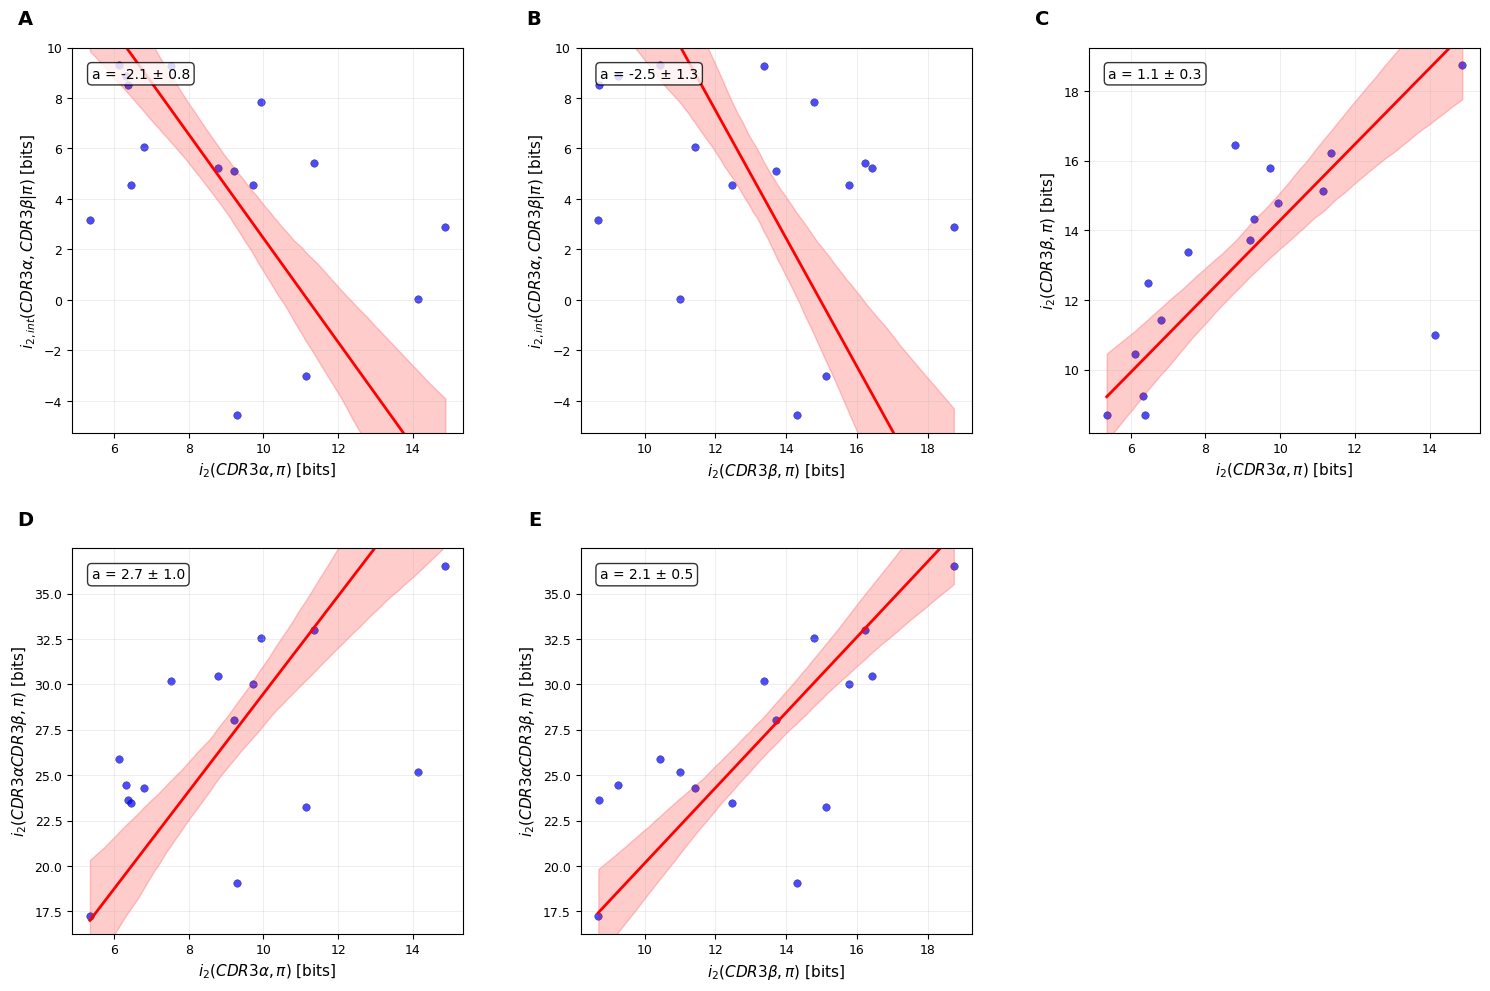

In [12]:
import scipy.odr as odr
import string

def round_up(x, decimal_places):
    return np.ceil(x * 10**decimal_places) / 10**decimal_places

def linear_func(p, x):
    a, b = p
    return a*x + b

def plot_fit(x, y, ax, color='blue', linestyle='-', intervals=True, decimal_places=1):
    """
    Perform ODR fitting and plot with confidence intervals
    """
    # Remove NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 2:
        return None
    
    # ODR fitting
    model = odr.Model(linear_func)
    data = odr.RealData(x_clean, y_clean)
    odr_fit = odr.ODR(data, model, beta0=[1.0, 0.0])
    out = odr_fit.run()
    
    # Plot data points
    ax.scatter(x_clean, y_clean, alpha=0.7, s=30, color=color, edgecolors='black', linewidth=0.3)
    
    # Plot fit line
    x_to_plot = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_fit = linear_func(out.beta, x_to_plot)
    ax.plot(x_to_plot, y_fit, c='red', linestyle=linestyle, linewidth=2)
    
    # Add confidence intervals
    if intervals:
        try:
            ps = np.random.multivariate_normal(out.beta, out.cov_beta, 1000)
            ysample = np.asarray([linear_func(pi, x_to_plot) for pi in ps])
            lower_bound = np.percentile(ysample, 2.5, axis=0)
            upper_bound = np.percentile(ysample, 97.5, axis=0)
            ax.fill_between(x_to_plot, lower_bound, upper_bound, color='red', alpha=0.2)
        except:
            pass  # Skip confidence intervals if covariance matrix is singular
    
    # Add parameter annotation
    slope, intercept = out.beta
    slope_err, intercept_err = out.sd_beta
    
    # Format the slope with error
    slope_rounded = round(slope, decimal_places)
    slope_err_rounded = round_up(slope_err, decimal_places)
    
    ax.text(0.05, 0.95, f'a = {slope_rounded:.{decimal_places}f} ± {slope_err_rounded:.{decimal_places}f}', 
            transform=ax.transAxes, verticalalignment='top', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            fontsize=10)
    
    return out

# Create the figure with 5 subplots (2x3 grid, last one empty)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Define the plot configurations
plot_configs = [
    {
        'x_col': 'alpha_info', 
        'y_col': 'syn', 
        'x_label': r"$i_2(CDR3\alpha, \pi)$ [bits]", 
        'y_label': r"$i_{2,int}(CDR3\alpha, CDR3\beta|\pi)$ [bits]", 
        'pos': (0, 0),
        'letter': 'A'
    },
    {
        'x_col': 'beta_info', 
        'y_col': 'syn', 
        'x_label': r"$i_2(CDR3\beta, \pi)$ [bits]", 
        'y_label': r"$i_{2,int}(CDR3\alpha, CDR3\beta|\pi)$ [bits]", 
        'pos': (0, 1),
        'letter': 'B'
    },
    {
        'x_col': 'alpha_info', 
        'y_col': 'beta_info', 
        'x_label': r"$i_2(CDR3\alpha, \pi)$ [bits]", 
        'y_label': r"$i_2(CDR3\beta, \pi)$ [bits]", 
        'pos': (0, 2),
        'letter': 'C'
    },
    {
        'x_col': 'alpha_info', 
        'y_col': 'full_sequence_info', 
        'x_label': r"$i_2(CDR3\alpha, \pi)$ [bits]", 
        'y_label': r"$i_2(CDR3\alpha CDR3\beta, \pi)$ [bits]", 
        'pos': (1, 0),
        'letter': 'D'
    },
    {
        'x_col': 'beta_info', 
        'y_col': 'full_sequence_info', 
        'x_label': r"$i_2(CDR3\beta, \pi)$ [bits]", 
        'y_label': r"$i_2(CDR3\alpha CDR3\beta, \pi)$ [bits]", 
        'pos': (1, 1),
        'letter': 'E'
    }
]

# Create each plot
for config in plot_configs:
    row, col = config['pos']
    ax = axes[row, col]
    
    # Get data
    x_data = mhc_data[config['x_col']].values
    y_data = mhc_data[config['y_col']].values
    
    # Perform fitting and plotting
    result = plot_fit(x_data, y_data, ax, color='blue', decimal_places=1)
    
    # Set labels and formatting
    ax.set_xlabel(config['x_label'], fontsize=11)
    ax.set_ylabel(config['y_label'], fontsize=11)
    
    # Add panel letter
    ax.text(-0.1, 1.05, config['letter'], transform=ax.transAxes, 
            fontsize=14, fontweight='bold', va='bottom', ha='right')
    
    # Grid and styling
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.tick_params(labelsize=9)
    
    # Set reasonable axis limits
    if result is not None:
        x_range = x_data[~np.isnan(x_data)]
        y_range = y_data[~np.isnan(y_data)]
        if len(x_range) > 0 and len(y_range) > 0:
            x_margin = (x_range.max() - x_range.min()) * 0.05
            y_margin = (y_range.max() - y_range.min()) * 0.05
            ax.set_xlim(x_range.min() - x_margin, x_range.max() + x_margin)
            ax.set_ylim(y_range.min() - y_margin, y_range.max() + y_margin)

# Remove the empty subplot
axes[1, 2].remove()

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Print fitting results
print("ODR Fitting Results:")
print("=" * 60)

for config in plot_configs:
    x_data = mhc_data[config['x_col']].values
    y_data = mhc_data[config['y_col']].values
    
    # Remove NaN values
    mask = ~(np.isnan(x_data) | np.isnan(y_data))
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) < 2:
        print(f"\nPanel {config['letter']}: Insufficient data points")
        continue
    
    try:
        model = odr.Model(linear_func)
        data = odr.RealData(x_clean, y_clean)
        odr_fit = odr.ODR(data, model, beta0=[1.0, 0.0])
        out = odr_fit.run()
        
        slope, intercept = out.beta
        slope_err, intercept_err = out.sd_beta
        
        print(f"\nPanel {config['letter']}:")
        print(f"  Slope (a): {slope:.3f} ± {slope_err:.3f}")
        print(f"  Intercept (b): {intercept:.3f} ± {intercept_err:.3f}")
        print(f"  Chi-square: {out.res_var:.6f}")
        print(f"  N points: {len(x_clean)}")
        
    except Exception as e:
        print(f"\nPanel {config['letter']}: Fitting failed - {e}")
plt.savefig("/mnt/d/TCRMI/figures/HLA/correlation_between_a_b_interaction_across_mhcs.pdf", transparent=True)

In [ ]:
def calculate_pmi(df, col1, col2, min_count=5):
    """
    Calculate PMI between two columns in a dataframe
    
    Parameters:
    df: dataframe
    col1: first column name
    col2: second column name
    min_count: minimum joint occurrence count for PMI calculation
    
    Returns:
    pmi_df: dataframe containing two columns and corresponding PMI values
    """
    # Calculate marginal probabilities
    col1_counts = df[col1].value_counts()
    col2_counts = df[col2].value_counts()
    total_count = len(df)
    
    col1_probs = col1_counts / total_count
    col2_probs = col2_counts / total_count
    
    # Calculate joint probabilities
    pair_counts = df.groupby([col1, col2]).size()
    pair_probs = pair_counts / total_count
    
    # Initialize results list
    pmi_results = []
    
    # Calculate PMI
    for (val1, val2), joint_count in pair_counts.items():
        if joint_count >= min_count:  # Filter rare combinations
            p_val1 = col1_probs[val1]
            p_val2 = col2_probs[val2]
            p_joint = pair_probs[(val1, val2)]
            
            pmi = math.log2(p_joint / (p_val1 * p_val2))
            npmi = pmi / (-math.log2(p_joint))  # Normalized PMI
            
            pmi_results.append({
                col1: val1,
                col2: val2,
                'joint_count': joint_count,
                'joint_prob': p_joint,
                'pmi': pmi,
                'npmi': npmi
            })
    
    return pd.DataFrame(pmi_results)

def calculate_pmi_difference(target_pmi_df, other_pmi_dfs, col1, col2):
    """
    Calculate PMI difference between target group and other groups
    
    Parameters:
    target_pmi_df: PMI dataframe of target group
    other_pmi_dfs: list of PMI dataframes of other groups
    col1: first column name
    col2: second column name
    
    Returns:
    diff_df: dataframe containing PMI differences
    """
    # Merge PMI dataframes of other groups
    all_other_pmi = pd.concat(other_pmi_dfs)
    
    # Calculate average PMI of other groups
    avg_other_pmi = all_other_pmi.groupby([col1, col2]).agg({
        'pmi': 'mean',
        'npmi': 'mean',
        'joint_count': 'sum'
    }).reset_index()
    avg_other_pmi.rename(columns={
        'pmi': 'other_pmi',
        'npmi': 'other_npmi',
        'joint_count': 'other_joint_count'
    }, inplace=True)
    
    # Merge target group and other groups' PMI
    merged_df = pd.merge(
        target_pmi_df, 
        avg_other_pmi, 
        on=[col1, col2], 
        how='left'
    )
    
    # Calculate PMI difference
    merged_df['pmi_diff'] = merged_df['pmi'] - merged_df['other_pmi']
    merged_df['npmi_diff'] = merged_df['npmi'] - merged_df['other_npmi']
    
    # Handle possible NaN values (when some combinations only appear in target group)
    merged_df['other_pmi'].fillna(0, inplace=True)
    merged_df['other_npmi'].fillna(0, inplace=True)
    merged_df['other_joint_count'].fillna(0, inplace=True)
    merged_df['pmi_diff'].fillna(merged_df['pmi'], inplace=True)
    merged_df['npmi_diff'].fillna(merged_df['npmi'], inplace=True)
    
    return merged_df

def assess_significance(target_df, all_dfs, group_col, col1, col2, n_permutations=1000, alpha=0.05):
    """
    Assess statistical significance of PMI differences using permutation test
    
    Parameters:
    target_df: original target group dataframe
    all_dfs: list of all group dataframes
    group_col: column name for group identification
    col1: first column name
    col2: second column name
    n_permutations: number of permutations
    alpha: significance level
    
    Returns:
    sig_df: PMI difference dataframe with significance markers
    """
    # Merge all dataframes
    all_data = pd.concat(all_dfs)
    all_data[f'{group_col}_orig'] = all_data[group_col]  # Save original groups
    
    # Calculate original PMI difference
    target_group = target_df[group_col].iloc[0]
    target_pmi = calculate_pmi(all_data[all_data[group_col] == target_group], col1, col2)
    other_pmi = calculate_pmi(all_data[all_data[group_col] != target_group], col1, col2)
    orig_pmi_diff = calculate_pmi_difference(target_pmi, [other_pmi], col1, col2)
    
    # Initialize permutation PMI difference list
    permutation_diffs = []
    
    # Perform permutation test
    for i in range(n_permutations):
        # Randomly shuffle group labels
        permuted_data = all_data.copy()
        permuted_data[group_col] = np.random.permutation(permuted_data[f'{group_col}_orig'])
        
        # Calculate PMI difference after permutation
        perm_target = permuted_data[permuted_data[group_col] == target_group]
        perm_others = permuted_data[permuted_data[group_col] != target_group]
        
        if len(perm_target) > 0 and len(perm_others) > 0:
            perm_target_pmi = calculate_pmi(perm_target, col1, col2)
            perm_others_pmi = calculate_pmi(perm_others, col1, col2)
            if not perm_target_pmi.empty and not perm_others_pmi.empty:
                perm_diff = calculate_pmi_difference(perm_target_pmi, [perm_others_pmi], col1, col2)
                permutation_diffs.append(perm_diff)
    
    # Calculate p-values
    p_values = []
    for idx, row in orig_pmi_diff.iterrows():
        val1, val2 = row[col1], row[col2]
        orig_diff = row['pmi_diff']
        
        # Count how many permutation differences are greater than original difference
        count_greater = 0
        total_valid = 0
        
        for perm_df in permutation_diffs:
            matching_rows = perm_df[(perm_df[col1] == val1) & (perm_df[col2] == val2)]
            if len(matching_rows) > 0:
                perm_diff = matching_rows['pmi_diff'].iloc[0]
                if perm_diff >= orig_diff:
                    count_greater += 1
                total_valid += 1
        
        # Calculate p-value
        if total_valid > 0:
            p_value = count_greater / total_valid
        else:
            p_value = 1.0
        
        p_values.append(p_value)
    
    # Add p-values to original difference dataframe
    orig_pmi_diff['p_value'] = p_values
    
    # Multiple testing correction
    if len(p_values) > 0:
        _, adjusted_p, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
        orig_pmi_diff['adjusted_p'] = adjusted_p
        orig_pmi_diff['significant'] = orig_pmi_diff['adjusted_p'] < alpha
    
    return orig_pmi_diff

def identify_key_v_gene_pairs(sig_pmi_df, top_n=20):
    """
    Identify key V gene pairs
    
    Parameters:
    sig_pmi_df: PMI difference dataframe with significance markers
    top_n: number of top V gene pairs to return
    
    Returns:
    key_pairs: key V gene pairs dataframe
    """
    # Filter significant V gene pairs
    significant_pairs = sig_pmi_df[sig_pmi_df['significant'] == True]
    
    # Sort by PMI difference
    sorted_pairs = significant_pairs.sort_values(by='pmi_diff', ascending=False)
    
    # Return top V gene pairs
    return sorted_pairs.head(top_n)


def visualize_key_pairs(HLAI, key_pairs_df, hla_type, col1='v.alpha', col2='v.beta', pmi_col='pmi_diff'):
    """
    Visualize key V gene pairs
    
    Parameters:
    HLAI: dataframe containing v.alpha and v.beta
    key_pairs_df: key V gene pairs dataframe containing col1, col2 and pmi_diff columns
    hla_type: HLA type name
    col1: alpha chain column name (default 'v.alpha')
    col2: beta chain column name (default 'v.beta')
    pmi_col: PMI difference value column name (default 'pmi_diff')
    """
    plt.figure(figsize=(14, 10))
    
    # Get unique v.alpha and v.beta values
    v_alpha_unique = HLAI[col1].unique()
    v_beta_unique = HLAI[col2].unique()
    
    # Create a DataFrame filled with zeros
    heatmap_data = pd.DataFrame(
        np.zeros((len(v_alpha_unique), len(v_beta_unique))), 
        index=v_alpha_unique,
        columns=v_beta_unique
    )
    
    # Fill pmi_diff values from key_pairs_df
    for _, row in key_pairs_df.iterrows():
        v_alpha = row[col1]
        v_beta = row[col2]
        if v_alpha in heatmap_data.index and v_beta in heatmap_data.columns:
            heatmap_data.loc[v_alpha, v_beta] = row[pmi_col]
    
    # Draw heatmap
    ax = sns.heatmap(
        heatmap_data, 
        cmap='coolwarm', 
        center=0,
        cbar_kws={'label': 'PMI Difference'}
    )
    
    plt.title(f'J-gene Pairs PMI Difference - {hla_type}\n'
              f'(Alpha: {len(v_alpha_unique)}, Beta: {len(v_beta_unique)})')
    plt.xlabel(f'{col2} Genes')
    plt.ylabel(f'{col1} Genes')
    plt.tight_layout()
    plt.savefig(f'/mnt/d/TCRMI/figures/HLA/key_j_gene_pairs_{hla_type}.pdf',bbox_inches='tight', transparent=True)

def analyze_hla_gene_pairs(HLAI, hla_types=['HLA-A*02:01', 'HLA-A*03:01', 'others'], 
                            col1='v.alpha', col2='v.beta', n_permutations=100):
    """
    Analyze PMI differences of V gene pairs in different HLA types and visualize results
    
    Parameters:
    HLAI: dataframe containing HLA and V gene information
    hla_types: list of HLA types to analyze
    col1: first V gene column name (default 'v.alpha')
    col2: second V gene column name (default 'v.beta')
    n_permutations: number of permutation tests
    """
    df = HLAI.copy()    
    # Create a dictionary to store dataframes for each HLA type
    hla_dfs_dict = {}
    
    # Classify data by HLA type
    for hla in hla_types:
        if hla == 'others':
            # Correctly filter data that doesn't belong to other specified HLA types
            mask = pd.Series(True, index=df.index)
            for h in [h for h in hla_types if h != 'others']:
                mask = mask & ~df['mhc.a'].str.contains(h, na=False, regex=False)
            hla_dfs_dict[hla] = df.loc[mask]
            hla_dfs_dict[hla] = hla_dfs_dict[hla].drop_duplicates(subset="full.tcr")
            hla_dfs_dict[hla]['hla_type'] = hla
        else:
            hla_dfs_dict[hla] = df.loc[df['mhc.a'].str.contains(hla, na=False, regex=False)]
            hla_dfs_dict[hla] = hla_dfs_dict[hla].drop_duplicates(subset="full.tcr")
            hla_dfs_dict[hla]['hla_type'] = hla

    # Get minimum shape and perform sampling
    min_shape = min(len(df_hla) for df_hla in hla_dfs_dict.values())
    min_shape = None
    print(min_shape)
    sampled_dfs = {}
    for hla in hla_types:
        df_hla = hla_dfs_dict[hla]
        if min_shape:
            if len(df_hla) > min_shape:
                sampled_dfs[hla] = df_hla.sample(min_shape, random_state=0)
            else:
                sampled_dfs[hla] = df_hla
        else:
            sampled_dfs[hla] = df_hla
    
    # Calculate PMI for each HLA type
    pmi_dfs = {}
    for hla in hla_types:
        pmi_df = calculate_pmi(sampled_dfs[hla], col1, col2)
        pmi_df['hla_type'] = hla
        pmi_dfs[hla] = pmi_df
    
    # Calculate PMI differences for each HLA type
    pmi_diff_dfs = {}
    for hla in hla_types:
        other_pmi_dfs = [pmi_dfs[other_hla] for other_hla in hla_types if other_hla != hla]
        pmi_diff_dfs[hla] = calculate_pmi_difference(pmi_dfs[hla], other_pmi_dfs, col1, col2)
    
    # Merge all dataframes for permutation test
    all_dfs = [sampled_dfs[hla] for hla in hla_types]
    
    # Assess significance for each HLA type
    sig_pmi_dfs = {}
    for hla in hla_types:
        sig_pmi_dfs[hla] = assess_significance(sampled_dfs[hla], all_dfs, 'hla_type', col1, col2, n_permutations=n_permutations)
    
    # Identify key V gene pairs for each HLA type
    key_pairs_dfs = {}
    for hla in hla_types:
        key_pairs_dfs[hla] = identify_key_v_gene_pairs(sig_pmi_dfs[hla])
    
    # Visualize key V gene pairs for each HLA type
    for hla in hla_types:
        display_name = hla if hla != 'others' else 'Others'
        visualize_key_pairs(HLAI, key_pairs_dfs[hla], display_name, col1, col2)
    
    return {
        'sampled_dfs': sampled_dfs,
        'pmi_dfs': pmi_dfs,
        'pmi_diff_dfs': pmi_diff_dfs,
        'sig_pmi_dfs': sig_pmi_dfs,
        'key_pairs_dfs': key_pairs_dfs
    }


None


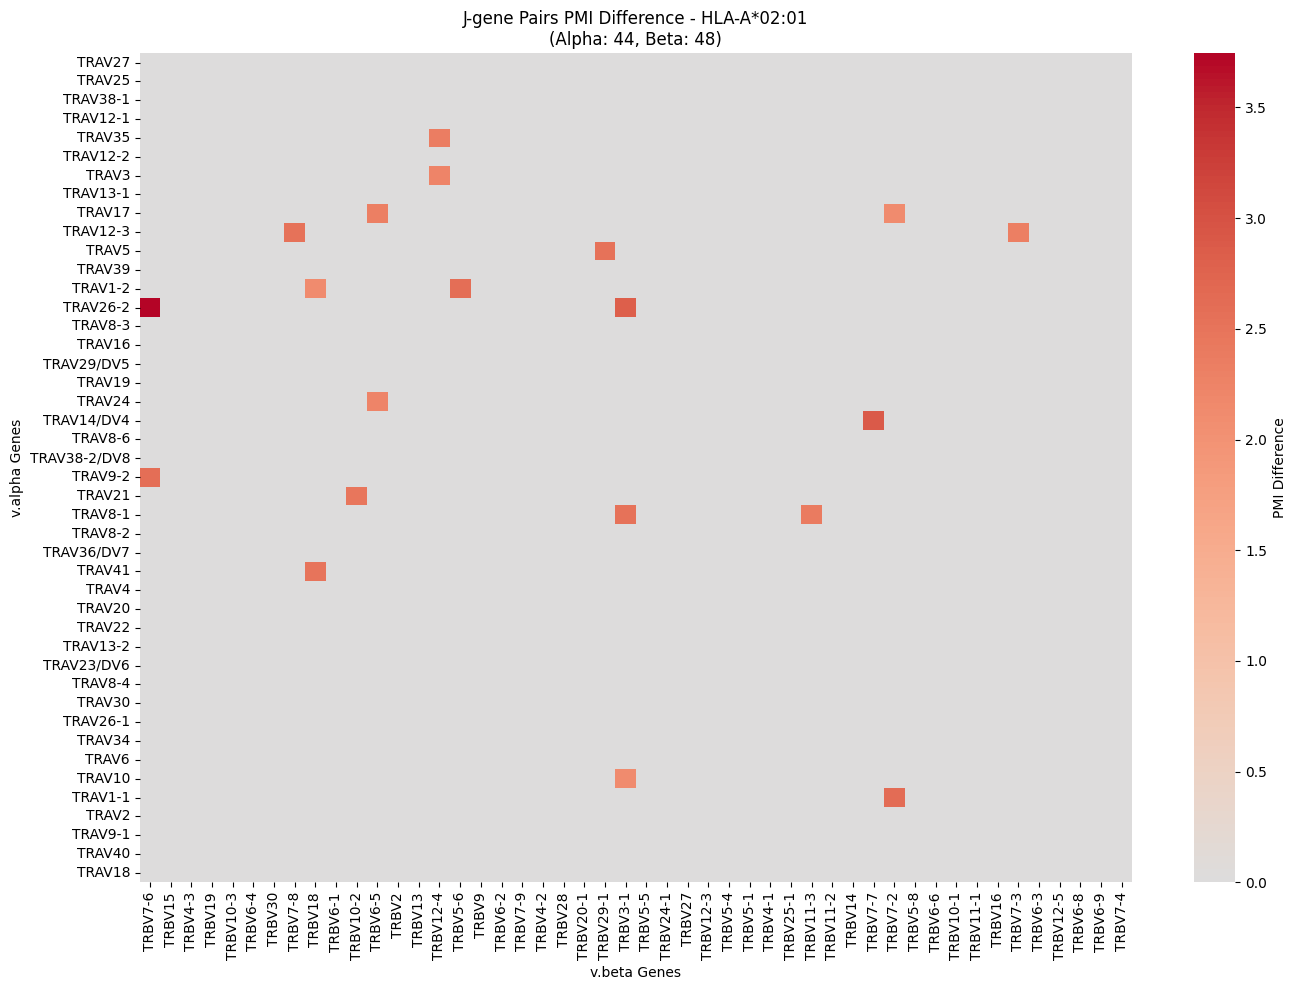

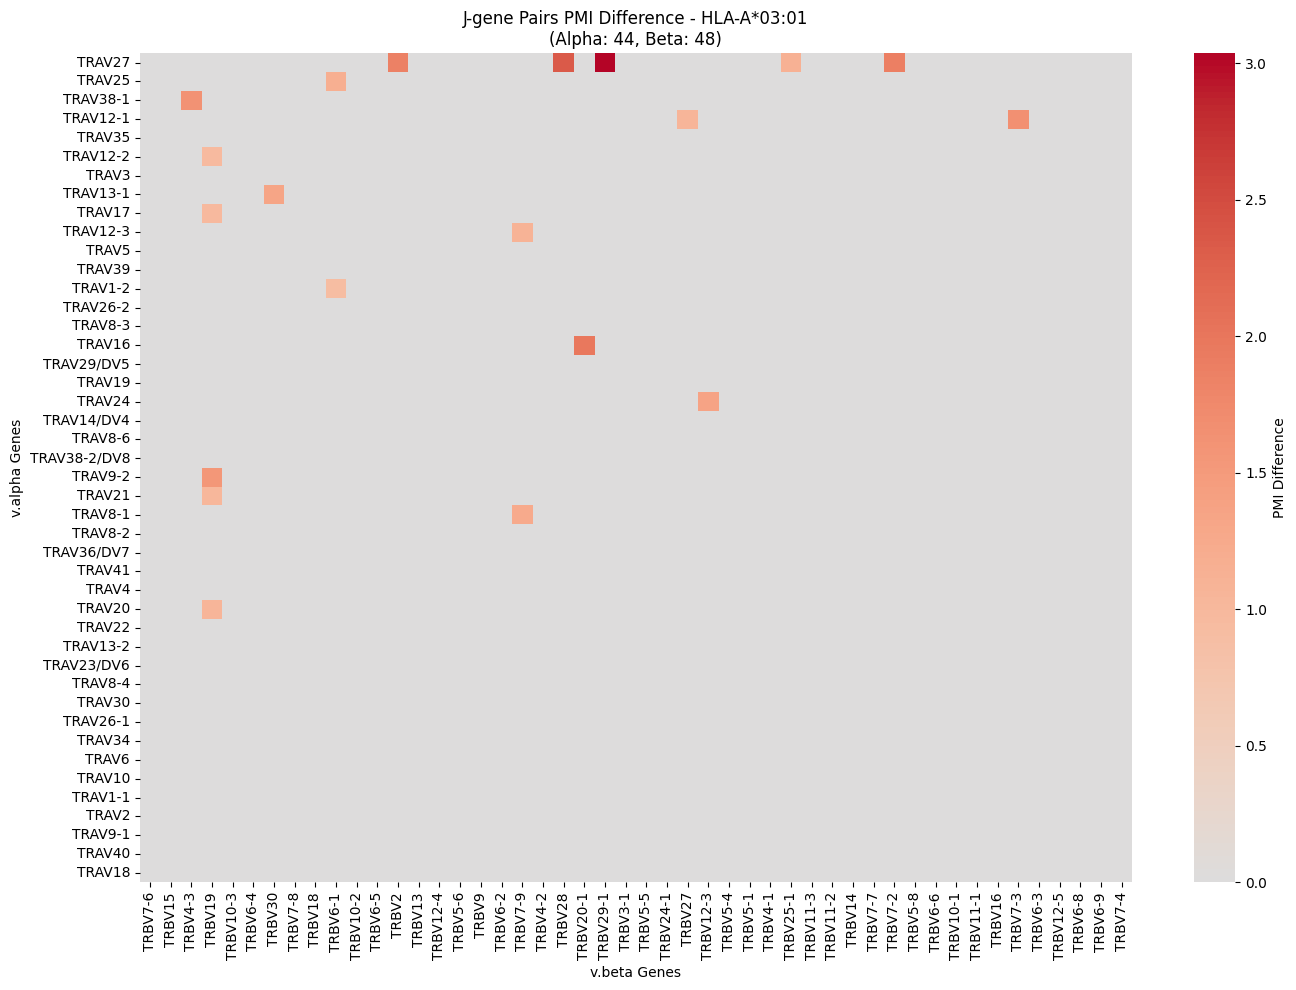

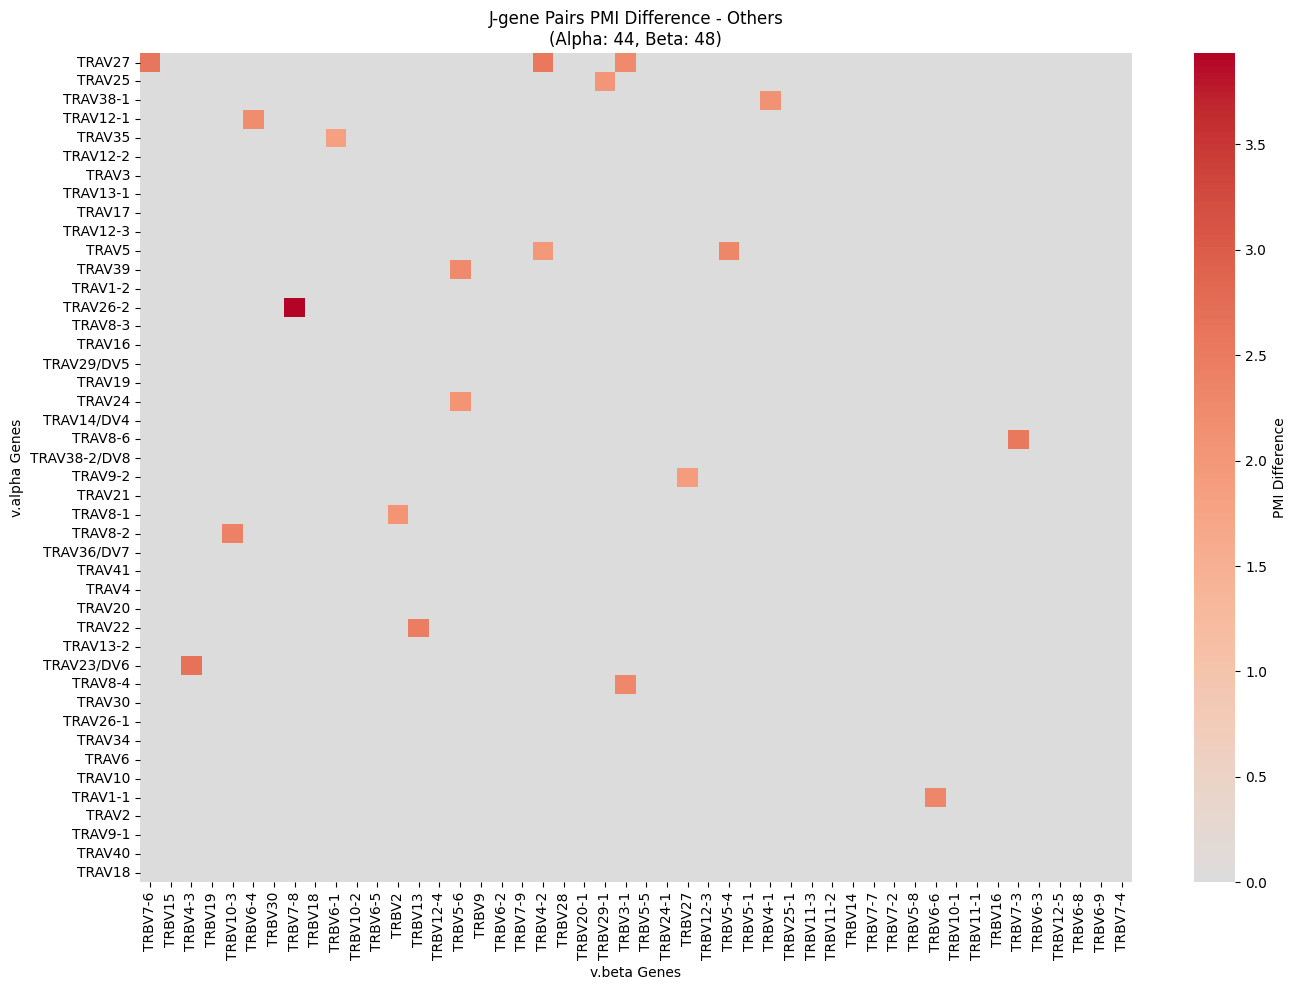

In [ ]:
results = analyze_hla_gene_pairs(HLAI, hla_types=['HLA-A*02:01', 'HLA-A*03:01', 'others'], col1='v.alpha', col2='v.beta', n_permutations=1000)

None


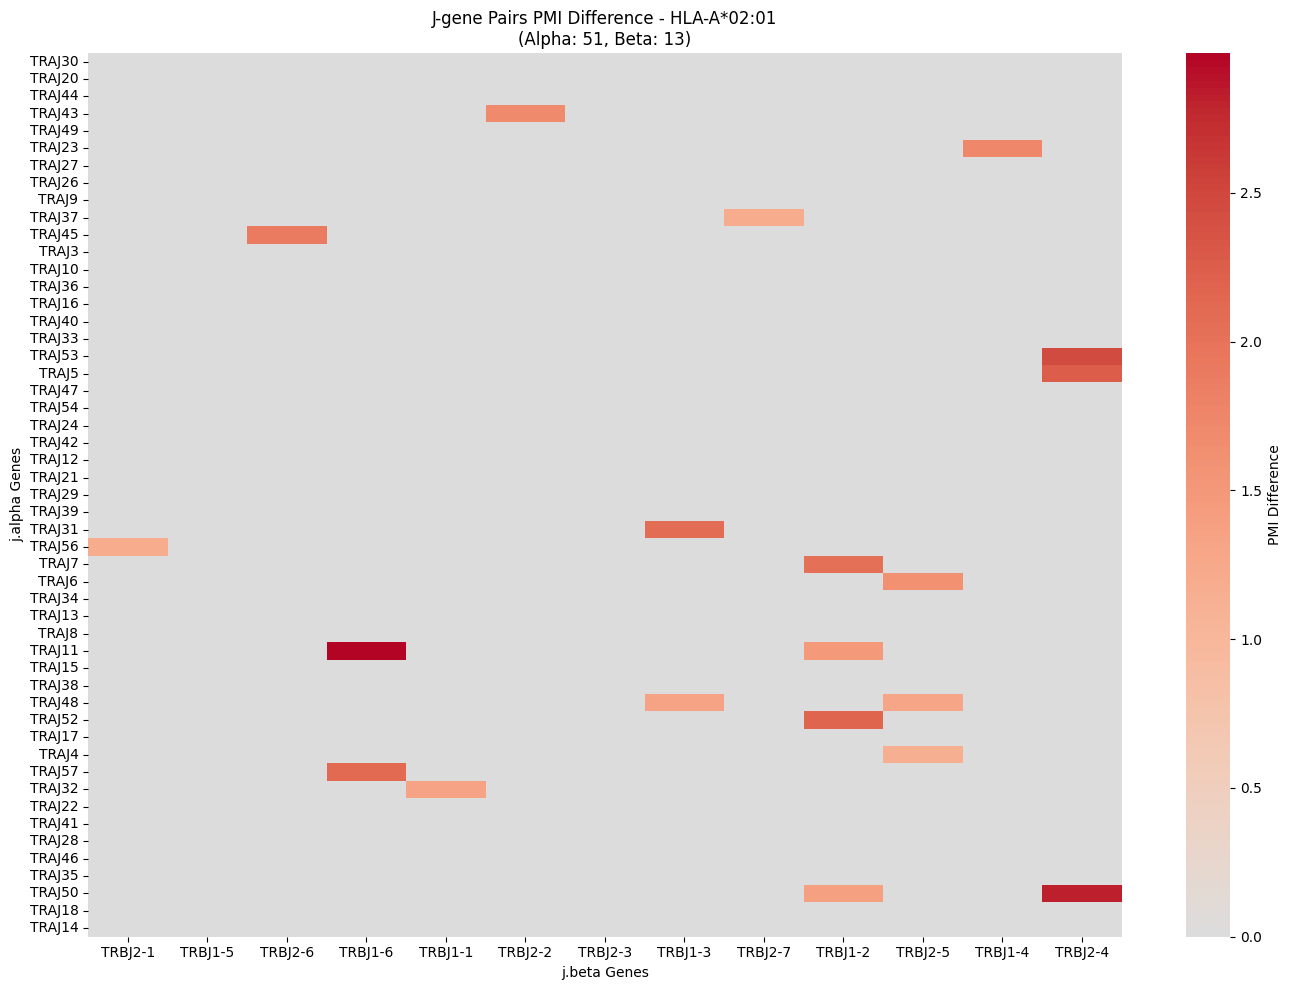

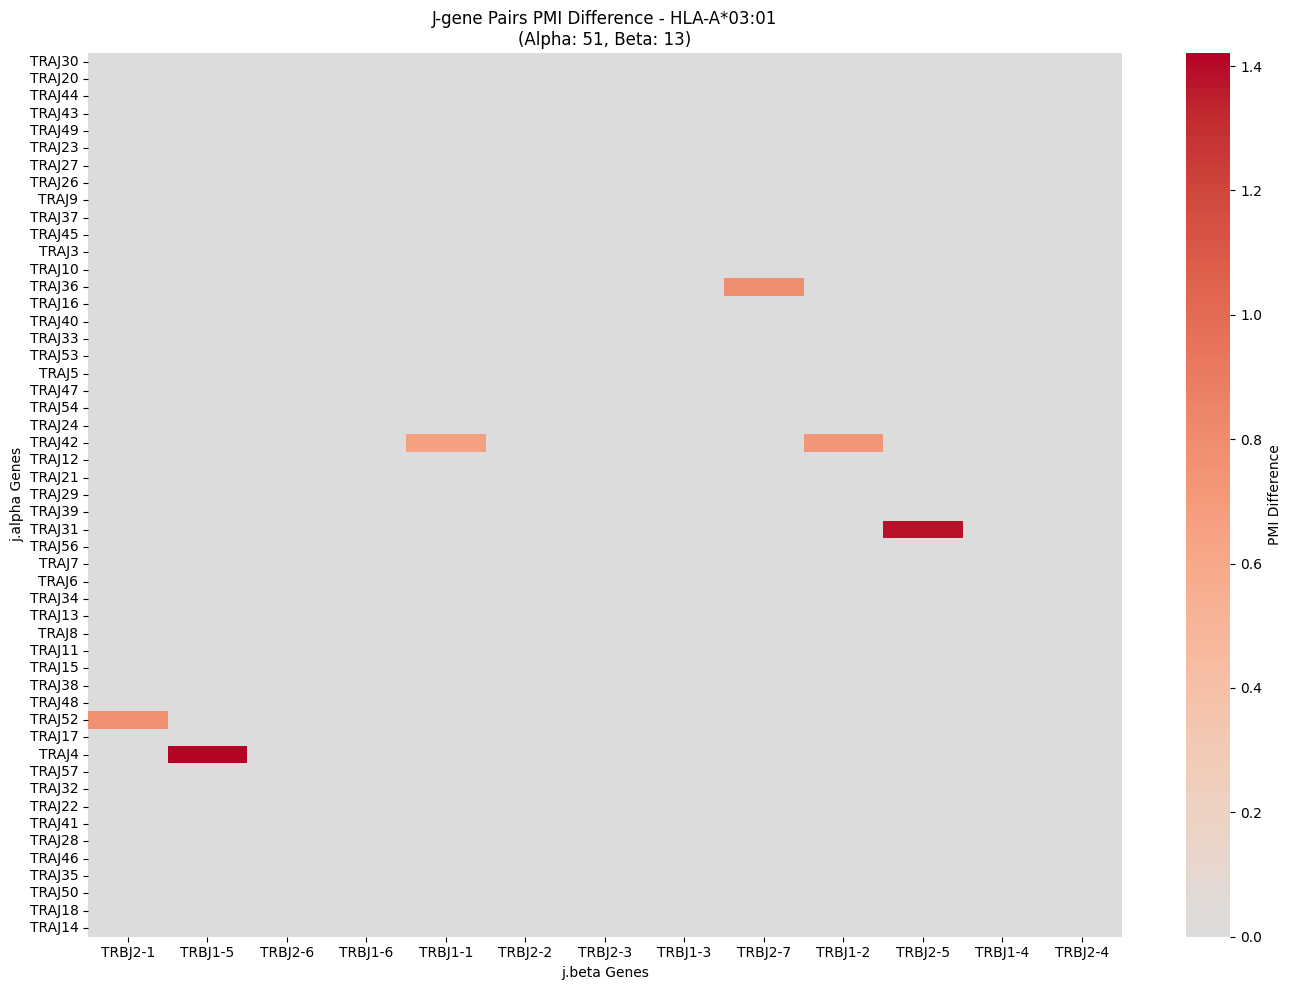

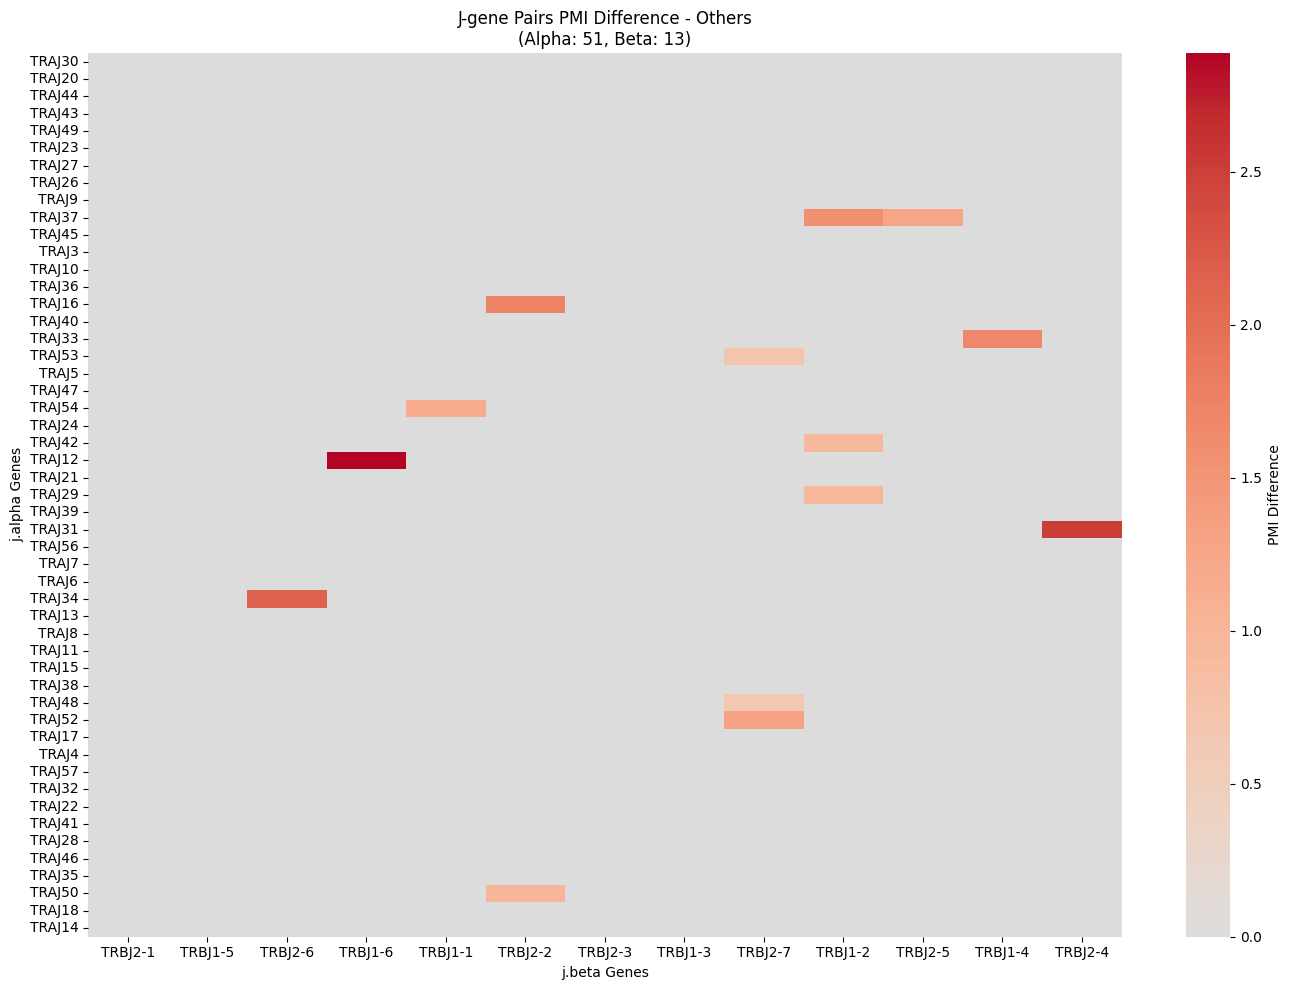

In [92]:
# 分析 v.beta 和 j.beta
results_beta_j = analyze_hla_gene_pairs(HLAI, hla_types=['HLA-A*02:01', 'HLA-A*03:01', 'others'], col1='j.alpha', col2='j.beta', n_permutations=1000)

## TCR-HLA association

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc_curves(val_labels, val_probs, test_labels, test_probs, n_classes=None, save_path=None):
    """
    Plot ROC curves for validation and test datasets (supports multi-class)
    
    Parameters:
    -----------
    val_labels : array-like
        True labels for validation set (can be multi-class: 0, 1, 2, 3, ...)
    val_probs : array-like
        Predicted probabilities for validation set (2D array with shape [n_samples, n_classes])
    test_labels : array-like
        True labels for test set (can be multi-class: 0, 1, 2, 3, ...)
    test_probs : array-like
        Predicted probabilities for test set (2D array with shape [n_samples, n_classes])
    n_classes : int, optional
        Number of classes. If None, will be inferred from val_probs shape or unique labels
    save_path : str, optional
        Path to save the plot. If None, plot will be displayed but not saved.
    
    Returns:
    --------
    dict : Dictionary containing AUC scores for both datasets
    """
    
    # Determine number of classes
    if n_classes is None:
        if val_probs.ndim == 2:
            n_classes = val_probs.shape[1]
        else:
            n_classes = len(np.unique(np.concatenate([val_labels, test_labels])))
    
    print(f"Number of classes: {n_classes}")
    
    # Handle binary vs multi-class cases
    if n_classes == 2:
        # Binary classification
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Extract probabilities for positive class (class 1)
        val_probs_pos = val_probs[:, 1] if val_probs.ndim == 2 else val_probs
        test_probs_pos = test_probs[:, 1] if test_probs.ndim == 2 else test_probs
        
        # Calculate ROC curves
        val_fpr, val_tpr, _ = roc_curve(val_labels, val_probs_pos)
        val_auc = auc(val_fpr, val_tpr)
        
        test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs_pos)
        test_auc = auc(test_fpr, test_tpr)
        
        # Plot validation ROC curve
        ax1.plot(val_fpr, val_tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {val_auc:.3f})')
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random classifier (AUC = 0.500)')
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.05])
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title('Validation Set - ROC Curve')
        ax1.legend(loc="lower right")
        ax1.grid(True, alpha=0.3)
        
        # Plot test ROC curve
        ax2.plot(test_fpr, test_tpr, color='darkorange', lw=2, 
                 label=f'ROC curve (AUC = {test_auc:.3f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random classifier (AUC = 0.500)')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('Test Set - ROC Curve')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)
        
        results = {
            'val_auc': val_auc,
            'test_auc': test_auc,
            'n_classes': n_classes
        }
        
    else:
        # Multi-class classification (One-vs-Rest approach)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        
        # Binarize labels for multi-class ROC
        classes = list(range(n_classes))
        val_labels_bin = label_binarize(val_labels, classes=classes)
        test_labels_bin = label_binarize(test_labels, classes=classes)
        
        # If only one class present, label_binarize returns 1D array
        if val_labels_bin.ndim == 1:
            val_labels_bin = val_labels_bin.reshape(-1, 1)
        if test_labels_bin.ndim == 1:
            test_labels_bin = test_labels_bin.reshape(-1, 1)
        
        # Colors for different classes
        colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
        
        val_auc_scores = {}
        test_auc_scores = {}
        
        # Calculate ROC curve for each class
        for i in range(n_classes):
            if i < len(colors):
                color = colors[i]
            else:
                color = np.random.rand(3,)  # Random color if we run out of predefined colors
            
            # Validation ROC
            if i < val_labels_bin.shape[1]:  # Check if class exists in validation set
                val_fpr, val_tpr, _ = roc_curve(val_labels_bin[:, i], val_probs[:, i])
                val_auc_class = auc(val_fpr, val_tpr)
                val_auc_scores[f'class_{i}'] = val_auc_class
                
                ax1.plot(val_fpr, val_tpr, color=color, lw=2, 
                         label=f'Class {i} (AUC = {val_auc_class:.3f})')
            
            # Test ROC
            if i < test_labels_bin.shape[1]:  # Check if class exists in test set
                test_fpr, test_tpr, _ = roc_curve(test_labels_bin[:, i], test_probs[:, i])
                test_auc_class = auc(test_fpr, test_tpr)
                test_auc_scores[f'class_{i}'] = test_auc_class
                
                ax2.plot(test_fpr, test_tpr, color=color, lw=2, 
                         label=f'Class {i} (AUC = {test_auc_class:.3f})')
        
        # Calculate macro-average AUC
        val_auc_macro = np.mean(list(val_auc_scores.values()))
        test_auc_macro = np.mean(list(test_auc_scores.values()))
        
        # Plot random classifier line
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random classifier')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                 label='Random classifier')
        
        # Formatting for validation plot
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.05])
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title(f'Validation Set - ROC Curves\n(Macro-avg AUC = {val_auc_macro:.3f})')
        ax1.legend(loc="lower right", fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Formatting for test plot
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title(f'Test Set - ROC Curves\n(Macro-avg AUC = {test_auc_macro:.3f})')
        ax2.legend(loc="lower right", fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        
    plt.tight_layout()
    
    # Save or show plot
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"ROC curves saved to: {save_path}")
    else:
        plt.show()


## 0203

Combined ROC curves saved to: /mnt/d/TCRMI/figures/HLA/0203ROC_Curve.pdf
Separate AUC radar charts saved to: /mnt/d/TCRMI/figures/HLA/0203AUC_Detailed_Radar.pdf


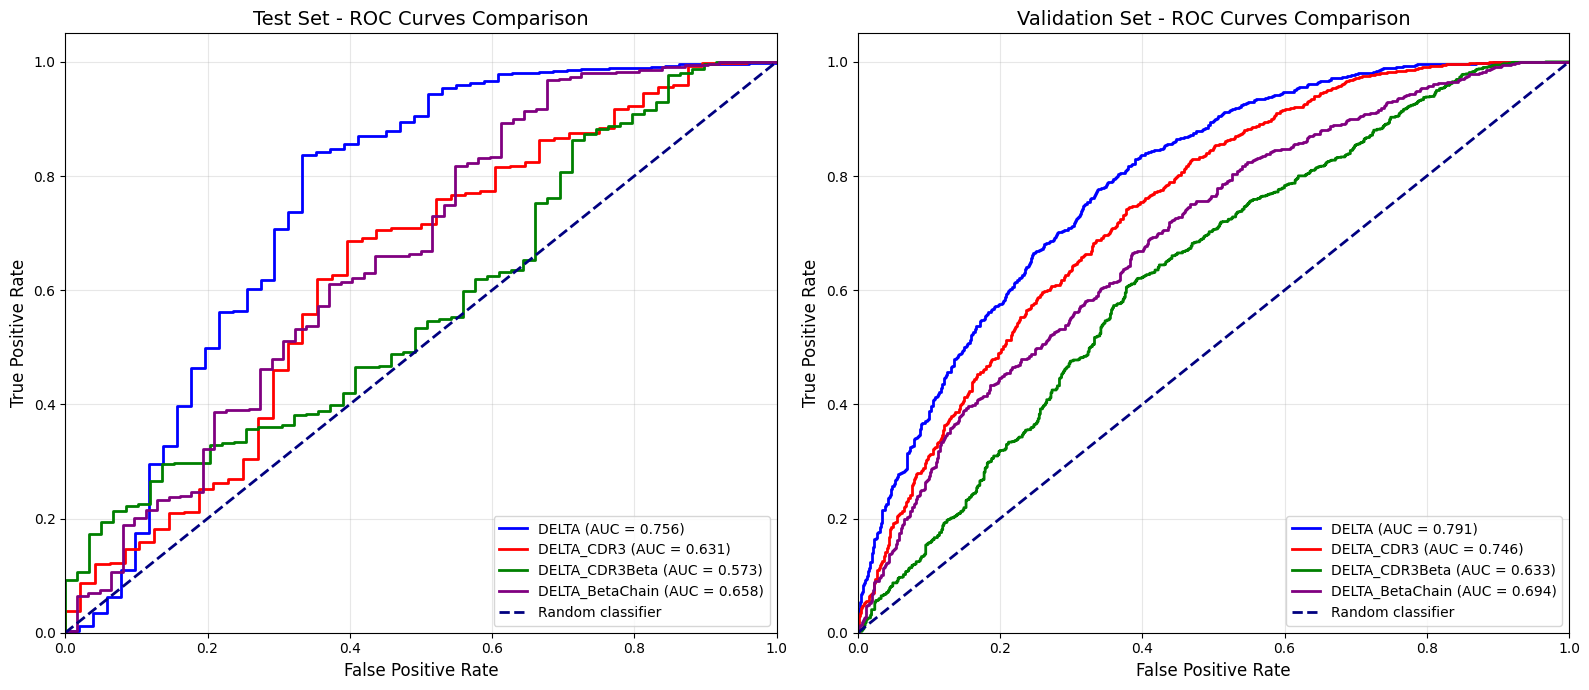

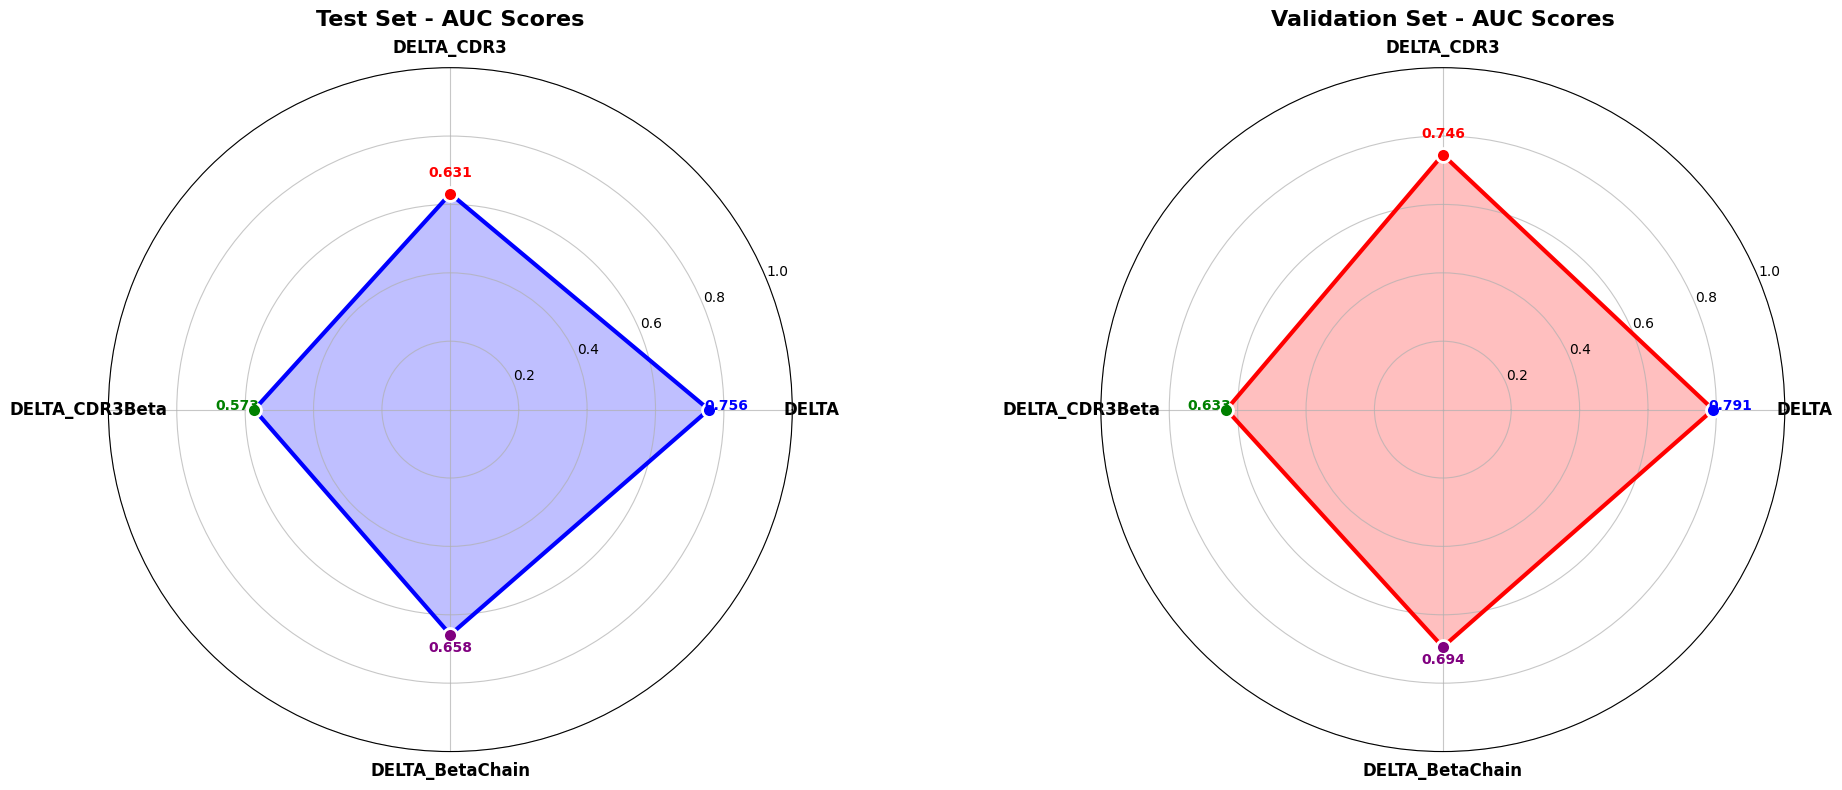

In [11]:
from math import pi
from sklearn.metrics import roc_curve, auc

def plot_separate_auc_radar_charts(test_auc_scores, val_auc_scores, save_path=None):
    """
    Create separate radar charts for test and validation sets
    """
    models = list(test_auc_scores.keys())
    N = len(models)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), subplot_kw=dict(projection='polar'))
    
    # Calculate angles for radar chart
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Colors for different models
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    # Plot Test Set Radar Chart
    test_values = [test_auc_scores[model] for model in models]
    test_values += test_values[:1]  # Complete the circle
    
    ax1.plot(angles, test_values, 'o-', linewidth=3, color='blue', markersize=8)
    ax1.fill(angles, test_values, alpha=0.25, color='blue')
    
    # Add individual model points with different colors
    for i, (angle, value, model) in enumerate(zip(angles[:-1], test_values[:-1], models)):
        ax1.plot(angle, value, 'o', color=colors[i % len(colors)], markersize=10, markeredgecolor='white', markeredgewidth=2)
        # Add value labels
        ax1.text(angle, value + 0.05, f'{value:.3f}', 
                horizontalalignment='center', fontsize=10, color=colors[i % len(colors)], fontweight='bold')
    
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(models, fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1)
    ax1.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
    ax1.grid(True, alpha=0.7)
    ax1.set_title('Test Set - AUC Scores', size=16, fontweight='bold', pad=30)
    
    # Plot Validation Set Radar Chart
    val_values = [val_auc_scores[model] for model in models]
    val_values += val_values[:1]  # Complete the circle
    
    ax2.plot(angles, val_values, 'o-', linewidth=3, color='red', markersize=8)
    ax2.fill(angles, val_values, alpha=0.25, color='red')
    
    # Add individual model points with different colors
    for i, (angle, value, model) in enumerate(zip(angles[:-1], val_values[:-1], models)):
        ax2.plot(angle, value, 'o', color=colors[i % len(colors)], markersize=10, markeredgecolor='white', markeredgewidth=2)
        # Add value labels
        ax2.text(angle, value + 0.05, f'{value:.3f}', 
                horizontalalignment='center', fontsize=10, color=colors[i % len(colors)], fontweight='bold')
    
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(models, fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10)
    ax2.grid(True, alpha=0.7)
    ax2.set_title('Validation Set - AUC Scores', size=16, fontweight='bold', pad=30)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', transparent=True)
        print(f"Separate AUC radar charts saved to: {save_path}")
    else:
        plt.show()

        
def plot_combined_roc_curves_both_sets(data_dict, save_path=None):
    """
    Plot ROC curves for multiple models showing both test and validation sets
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    test_auc_scores = {}
    val_auc_scores = {}
    
    for idx, (model_name, model_data) in enumerate(data_dict.items()):
        color = colors[idx % len(colors)]
        
        # Process test data
        test_labels = model_data['test_labels']
        test_probs = model_data['test_probs']
        
        if test_probs.ndim == 2 and test_probs.shape[1] == 2:
            test_probs_pos = test_probs[:, 1]
        else:
            test_probs_pos = test_probs
            
        test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs_pos)
        test_auc = auc(test_fpr, test_tpr)
        test_auc_scores[model_name] = test_auc
        
        # Process validation data
        val_labels = model_data['val_labels']
        val_probs = model_data['val_probs']
        
        if val_probs.ndim == 2 and val_probs.shape[1] == 2:
            val_probs_pos = val_probs[:, 1]
        else:
            val_probs_pos = val_probs
            
        val_fpr, val_tpr, _ = roc_curve(val_labels, val_probs_pos)
        val_auc = auc(val_fpr, val_tpr)
        val_auc_scores[model_name] = val_auc
        
        # Plot test ROC curve
        ax1.plot(test_fpr, test_tpr, color=color, lw=2, 
                 label=f'{model_name} (AUC = {test_auc:.3f})')
        
        # Plot validation ROC curve
        ax2.plot(val_fpr, val_tpr, color=color, lw=2, 
                 label=f'{model_name} (AUC = {val_auc:.3f})')
    
    # Add random classifier lines
    for ax in [ax1, ax2]:
        ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
                label='Random classifier')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3)
    
    ax1.set_title('Test Set - ROC Curves Comparison', fontsize=14)
    ax2.set_title('Validation Set - ROC Curves Comparison', fontsize=14)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', transparent=True)
        print(f"Combined ROC curves saved to: {save_path}")
    else:
        plt.show()
    
    return {'test_auc': test_auc_scores, 'val_auc': val_auc_scores}

# Load your data
DELTA = np.load("/mnt/d/TCRMI/results/log/attention/auc_datatcrhlastrict0203_attention2.npy", allow_pickle=True).item()
DELTA_cdr3 = np.load("/mnt/d/TCRMI/results/log/attention/auc_datatcrhlastrict0203_attention2cdr3.npy", allow_pickle=True).item()
DELTA_cdr3beta = np.load("/mnt/d/TCRMI/results/log/attention/auc_data_tcrhlastrict0203_attention2_betacdr3.npy", allow_pickle=True).item()
DELTA_betachain = np.load("/mnt/d/TCRMI/results/log/attention/auc_data_tcrhlastrict0203_attention2_beta.npy", allow_pickle=True).item()

# Create a dictionary with all models
models_data = {
    'DELTA': DELTA,
    'DELTA_CDR3': DELTA_cdr3,
    'DELTA_CDR3Beta': DELTA_cdr3beta,
    'DELTA_BetaChain': DELTA_betachain
}

# Use this version to plot both sets
results = plot_combined_roc_curves_both_sets(models_data, save_path="/mnt/d/TCRMI/figures/HLA/0203ROC_Curve.pdf")

plot_separate_auc_radar_charts(
    results['test_auc'], 
    results['val_auc'], 
    save_path="/mnt/d/TCRMI/figures/HLA/0203AUC_Detailed_Radar.pdf"
)